In [1]:
# Date resolution: prefer CLI -> .env -> config
try:
    from src.utils.config_utils import resolve_date
    start_date = resolve_date(None, "date_range.default_start") or (pd.Timestamp.today() - pd.Timedelta(days=365)).strftime('%Y-%m-%d')
    end_date = resolve_date(None, "date_range.default_end") or pd.Timestamp.today().strftime('%Y-%m-%d')
    train_end = resolve_date(None, "date_range.train_end") or (pd.Timestamp.today() - pd.Timedelta(days=365)).strftime('%Y-%m-%d')
    test_start = resolve_date(None, "date_range.test_start") or (pd.Timestamp.today() - pd.Timedelta(days=364)).strftime('%Y-%m-%d')
except Exception:
    start_date = (pd.Timestamp.today() - pd.Timedelta(days=365)).strftime('%Y-%m-%d')
    end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
    train_end = (pd.Timestamp.today() - pd.Timedelta(days=365)).strftime('%Y-%m-%d')
    test_start = (pd.Timestamp.today() - pd.Timedelta(days=364)).strftime('%Y-%m-%d')
print(f"Date range: {start_date} → {end_date} (train_end={train_end}, test_start={test_start})")

NameError: name 'pd' is not defined

# Notebook 02 — Satellite & Reanalysis Feature Exploration

This notebook explores the gridded satellite and meteorological features that
drive the AQI models:

- Feature maps for a selected day (NO₂, AOD, wind vectors)
- Feature–PM2.5 Pearson correlations
- Seasonal patterns: monsoon vs. post-monsoon for the Indo-Gangetic Plain
- Multi-variable time series aggregated over the IGP

> Synthetic data is generated automatically if `data/processed/grid_daily_features.csv`
> is not found.

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Gridded Feature Dataset

The grid uses a 0.1° regular lat/lon covering India (8–37.5°N, 68–97.5°E).
Each row is one grid cell on one day with 13 satellite + met features.

In [3]:
grid_path = Path('../data/processed/grid_daily_features.csv')

FEATURE_COLS = [
    'no2_column', 'so2_column', 'co_column', 'o3_column',
    'hcho_column', 'insat_aod',
    't2m', 'rh2m', 'u10', 'v10', 'tp', 'sp', 'blh',
]

if grid_path.exists():
    df = pd.read_csv(grid_path, parse_dates=['date'])
    print(f'✓ Loaded real grid data: {df.shape}')
else:
    print('Grid CSV not found — generating synthetic demo grid…')
    rng = np.random.default_rng(7)
    lats = np.arange(8.0, 37.5, 0.5)   # coarser for demo speed
    lons = np.arange(68.0, 97.5, 0.5)
    dates = pd.date_range(start_date, end_date, freq='10D')
    records = []
    for d in dates:
        m = d.month
        monsoon = m in (6, 7, 8, 9)
        winter  = m in (12, 1, 2)
        for lat in lats:
            for lon in lons:
                igp = (23 <= lat <= 30) and (75 <= lon <= 90)
                s_no2 = 1.6 if winter else (0.7 if monsoon else 1.0)
                records.append({
                    'date': d, 'lat': round(lat, 1), 'lon': round(lon, 1),
                    'no2_column':  max(0, rng.lognormal(10.5, 0.4) * s_no2 * (1.4 if igp else 1.0)),
                    'so2_column':  max(0, rng.lognormal(9.5,  0.5) * s_no2),
                    'co_column':   max(0, rng.lognormal(15.0, 0.3) * s_no2),
                    'o3_column':   max(0, rng.lognormal(14.5, 0.2) * (1.2 if not monsoon else 0.8)),
                    'hcho_column': max(0, rng.lognormal(14.8, 0.4) * (1.3 if monsoon else 0.9)),
                    'insat_aod':   max(0, rng.lognormal(-0.3, 0.5) * s_no2 * (1.3 if igp else 1.0)),
                    't2m':         20 + 10 * np.sin(2*np.pi*d.dayofyear/365) + (lat-28)*(-0.5) + rng.normal(0,1),
                    'rh2m':        40 + 35 * np.sin(2*np.pi*(d.dayofyear-90)/365) + rng.normal(0,5),
                    'u10':         rng.normal(2, 3),
                    'v10':         rng.normal(0, 2),
                    'tp':          max(0, rng.exponential(0.5) if monsoon else rng.exponential(0.05)),
                    'sp':          1010 + (lat - 22) * (-2) + rng.normal(0, 2),
                    'blh':         max(100, rng.lognormal(6.5, 0.4) * (2 if not winter else 0.4)),
                    'pm25_target': max(0, rng.lognormal(3.2, 0.5) * (1.7 if winter else 0.65 if monsoon else 1) * (1.4 if igp else 1)),
                })
    df = pd.DataFrame(records)
    print(f'✓ Synthetic grid: {df.shape}')

df['date'] = pd.to_datetime(df['date'])
available_feats = [f for f in FEATURE_COLS if f in df.columns]
print(f'Features available: {available_feats}')
df.head(3)

✓ Loaded real grid data: (529400, 18)
Features available: ['no2_column', 'so2_column', 'co_column', 'o3_column', 'hcho_column', 'insat_aod', 't2m', 'rh2m', 'u10', 'v10', 'tp', 'sp', 'blh']


,cell_id,lat,lon,date,no2_column,so2_column,co_column,o3_column,hcho_column,insat_aod,t2m,rh2m,u10,v10,tp,sp,blh,fire_count
0,CELL_14.85_72.95,14.85,72.95,2019-01-01,59.137423,21.883492,1.914347,94.280604,32.020911,0.250340,288.641722,75.775763,1.949597,-0.706088,0.000211,96555.583871,1228.415887,0
1,CELL_35.75_78.25,35.75,78.25,2019-01-01,75.512640,30.657075,2.110000,65.788895,52.041404,0.577511,287.703613,70.305459,5.667624,0.690941,0.001967,94295.732899,1368.299434,0
2,CELL_20.65_90.15,20.65,90.15,2019-01-01,64.624323,38.524877,2.567492,74.075908,45.419754,0.362267,290.106139,97.453986,1.658158,-0.680313,0.002637,96301.185576,1431.582929,0


## 2. Single-Day Feature Maps

We plot NO₂, INSAT AOD, and 10-m wind vectors for a selected day.
- **NO₂** is highest over the IGP and major industrial corridors
- **AOD** tracks aerosol loading — highest in pre-monsoon (dust) and post-monsoon (burning)
- **Wind vectors** show the prevailing flow that transports pollutants

Selected date: 2022-11-16  |  rows: 200


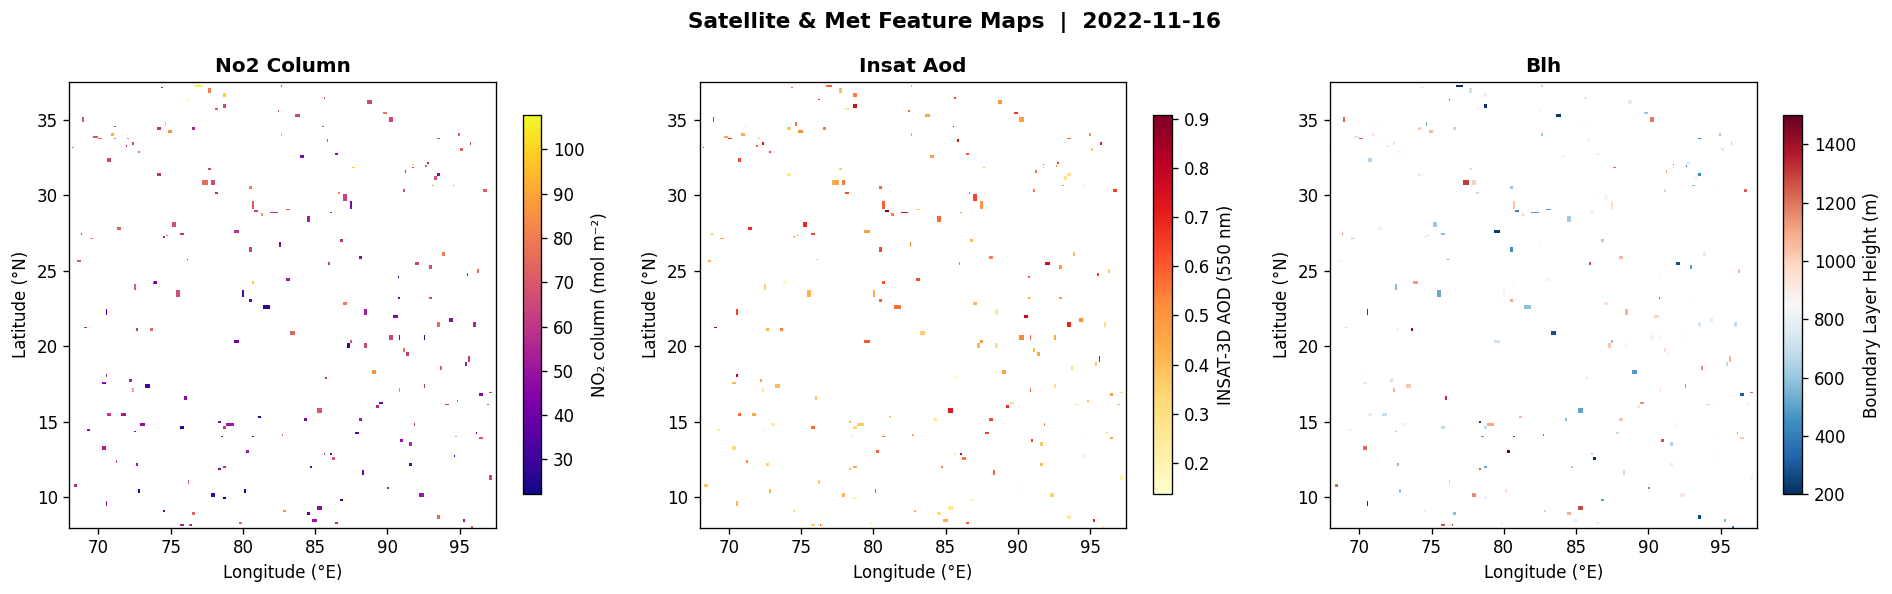

In [4]:
# Pick a representative post-monsoon day
target_month = 11  # November (post-monsoon)
day_dates = df[df['date'].dt.month == target_month]['date'].unique()
sel_date = pd.Timestamp(day_dates[len(day_dates)//2]) if len(day_dates) > 0 else df['date'].iloc[0]
day = df[df['date'] == sel_date].copy()
print(f'Selected date: {sel_date.date()}  |  rows: {len(day)}')

def pivot_feature(day_df, col):
    return day_df.pivot_table(index='lat', columns='lon', values=col, aggfunc='mean')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, cmap, label in [
    (axes[0], 'no2_column',  'plasma',   'NO₂ column (mol m⁻²)'),
    (axes[1], 'insat_aod',   'YlOrRd',   'INSAT-3D AOD (550 nm)'),
    (axes[2], 'blh',         'RdBu_r',   'Boundary Layer Height (m)'),
]:
    if col not in day.columns:
        ax.set_title(f'{col} not available')
        continue
    piv = pivot_feature(day, col)
    im = ax.pcolormesh(piv.columns, piv.index, piv.values,
                       cmap=cmap, shading='auto')
    plt.colorbar(im, ax=ax, label=label, shrink=0.85)
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlim(68, 97.5); ax.set_ylim(8, 37.5)

    if col == 'no2_column' and 'u10' in day.columns:
        skip = max(1, len(piv.columns)//20)
        lons_q = piv.columns[::skip]
        lats_q = piv.index[::skip]
        u_piv = pivot_feature(day, 'u10').reindex(index=lats_q, columns=lons_q)
        v_piv = pivot_feature(day, 'v10').reindex(index=lats_q, columns=lons_q)
        LON, LAT = np.meshgrid(lons_q, lats_q)
        ax.quiver(LON, LAT, u_piv.values, v_piv.values,
                  scale=200, width=0.003, color='white', alpha=0.7)

fig.suptitle(f'Satellite & Met Feature Maps  |  {sel_date.date()}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature–PM2.5 Correlations

Understanding which satellite/met features are most correlated with observed PM2.5
helps explain model decisions and guides feature selection.

In [5]:
if 'pm25_target' in df.columns:
    sub = df[available_feats + ['pm25_target']].dropna()
    corr = sub.corr()['pm25_target'].drop('pm25_target').sort_values()

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#d32f2f' if v < 0 else '#1565c0' for v in corr.values]
    bars = ax.barh(corr.index, corr.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Pearson r with PM2.5')
    ax.set_title('Feature Correlations with PM2.5 (ground truth)', fontweight='bold')
    for bar, val in zip(bars, corr.values):
        x = bar.get_width()
        ax.text(x + (0.01 if x >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left' if x >= 0 else 'right', fontsize=8)
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('\nTop 5 positive correlates:')
    print(corr.nlargest(5).to_string())
    print('\nTop 5 negative correlates:')
    print(corr.nsmallest(5).to_string())
else:
    print('pm25_target not in dataset — skipping correlation analysis')

pm25_target not in dataset — skipping correlation analysis


## 4. Seasonal Pattern Analysis — Indo-Gangetic Plain vs Rest of India

The IGP (23–30°N, 75–90°E) is one of the world’s most polluted airsheds.
We compare monthly mean NO₂ and AOD for IGP vs the rest of India.

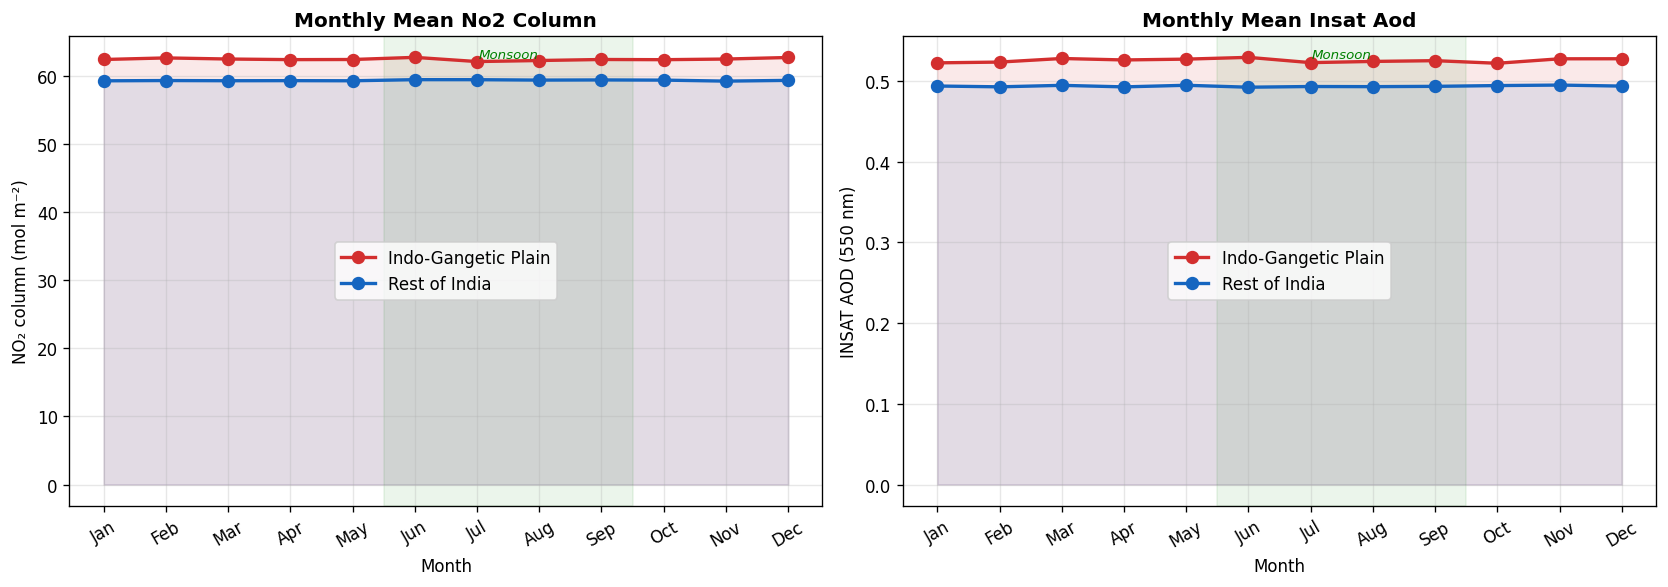

In [6]:
df['month'] = df['date'].dt.month
df['region'] = 'Rest of India'
igp_mask = (df['lat'] >= 23) & (df['lat'] <= 30) & (df['lon'] >= 75) & (df['lon'] <= 90)
df.loc[igp_mask, 'region'] = 'Indo-Gangetic Plain'

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, ylabel in [
    (axes[0], 'no2_column',  'NO₂ column (mol m⁻²)'),
    (axes[1], 'insat_aod',   'INSAT AOD (550 nm)'),
]:
    if feat not in df.columns:
        continue
    monthly = df.groupby(['region', 'month'])[feat].mean().reset_index()
    for region, color in [('Indo-Gangetic Plain', '#d32f2f'), ('Rest of India', '#1565c0')]:
        sub_r = monthly[monthly['region'] == region].sort_values('month')
        ax.plot(sub_r['month'], sub_r[feat], 'o-', color=color,
                linewidth=2, markersize=7, label=region)
        ax.fill_between(sub_r['month'], sub_r[feat], alpha=0.1, color=color)
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_names, rotation=30)
    ax.set_ylabel(ylabel); ax.set_xlabel('Month')
    ax.set_title(f'Monthly Mean {feat.replace("_", " ").title()}', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    # Shade monsoon
    ax.axvspan(5.5, 9.5, alpha=0.08, color='green')
    ax.text(7.5, ax.get_ylim()[1]*0.95, 'Monsoon', ha='center',
            fontsize=8, color='green', style='italic')

plt.tight_layout()
plt.show()

## 5. Multi-Feature Time Series (IGP)

Plotting all key features together for the IGP shows how satellite and met
variables co-vary with PM2.5 across seasons.

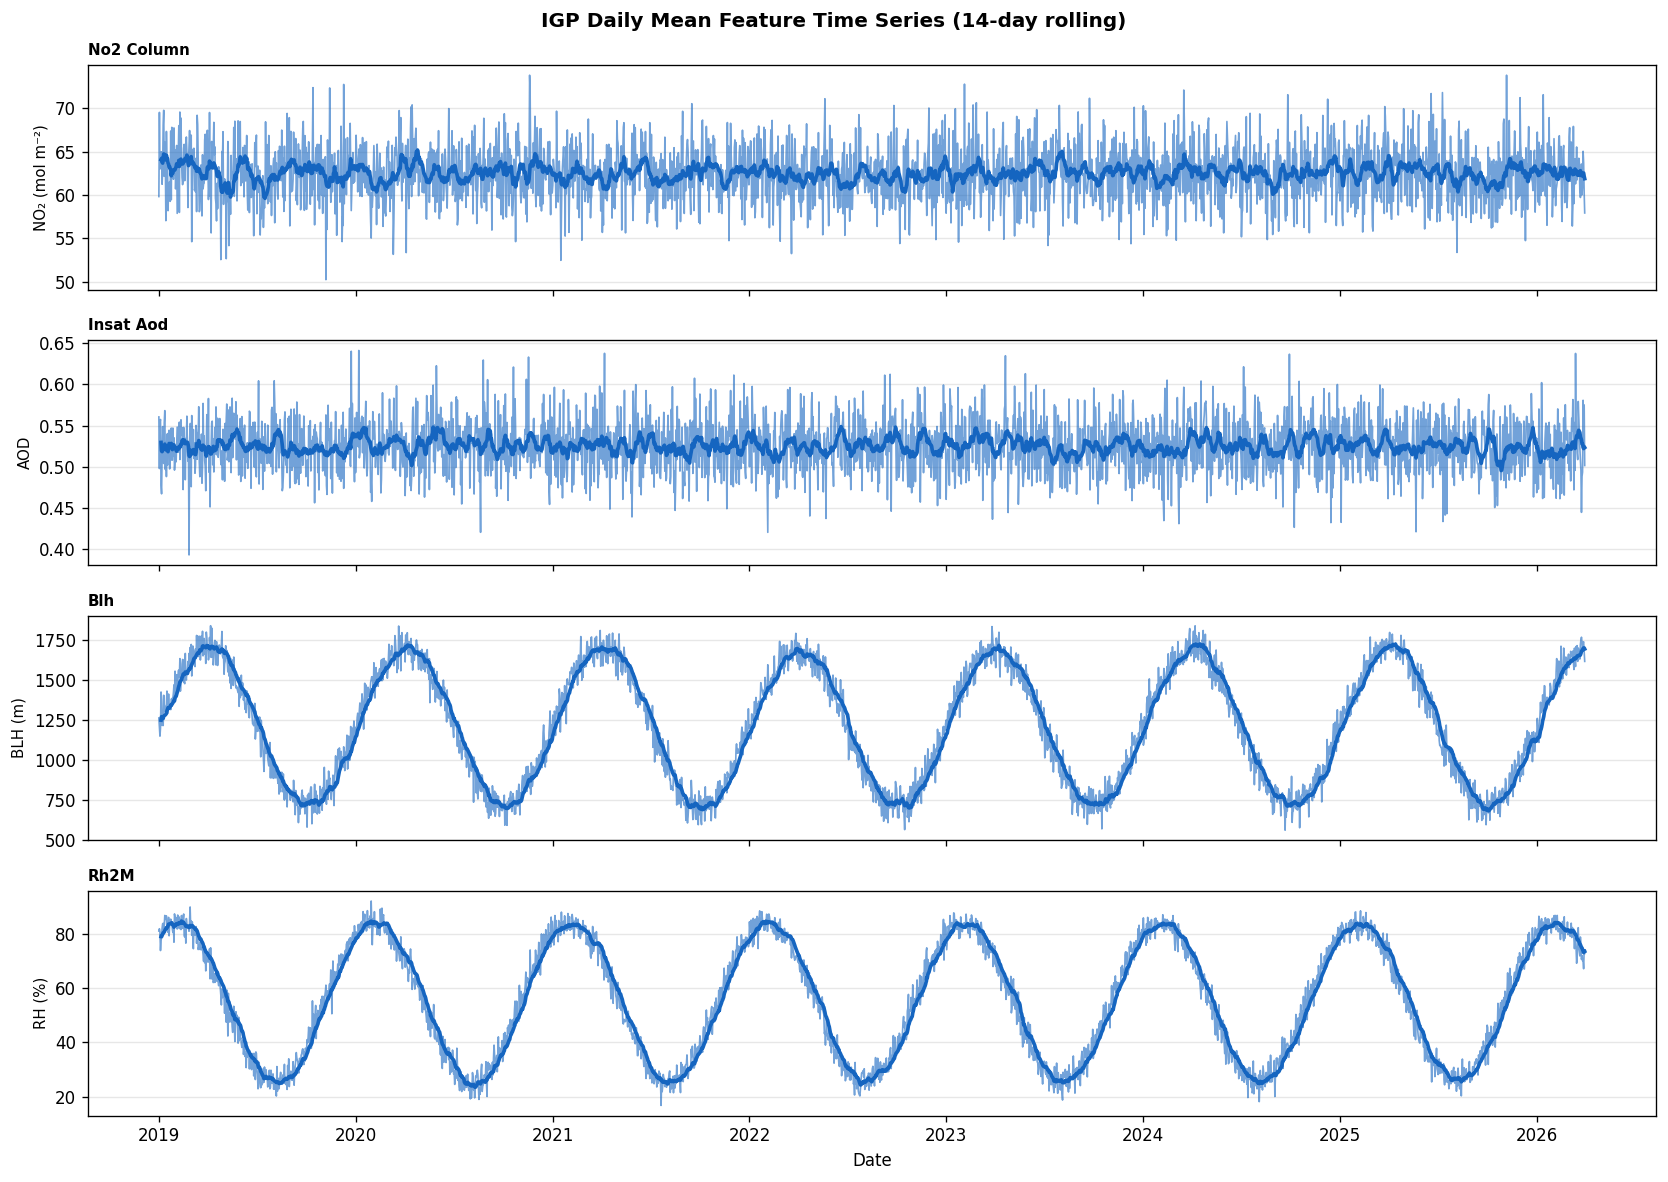

In [7]:
igp_daily = (
    df[df['region'] == 'Indo-Gangetic Plain']
    .groupby('date')[available_feats + (['pm25_target'] if 'pm25_target' in df.columns else [])]
    .mean()
    .sort_index()
)

plot_feats = [f for f in ['no2_column','insat_aod','blh','rh2m','pm25_target']
              if f in igp_daily.columns]
ylabels = {
    'no2_column':  'NO₂ (mol m⁻²)',
    'insat_aod':   'AOD',
    'blh':         'BLH (m)',
    'rh2m':        'RH (%)',
    'pm25_target': 'PM2.5 (µg m⁻³)',
}

fig, axes = plt.subplots(len(plot_feats), 1, figsize=(14, 2.5*len(plot_feats)), sharex=True)
if len(plot_feats) == 1:
    axes = [axes]

for ax, feat in zip(axes, plot_feats):
    color = '#d32f2f' if feat == 'pm25_target' else '#1565c0'
    ax.plot(igp_daily.index, igp_daily[feat], color=color, linewidth=1, alpha=0.6)
    ax.plot(igp_daily.index, igp_daily[feat].rolling(14, min_periods=5).mean(),
            color=color, linewidth=2.2)
    ax.set_ylabel(ylabels.get(feat, feat), fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_title(feat.replace('_',' ').title(), loc='left', fontsize=9, fontweight='bold')

axes[-1].set_xlabel('Date')
fig.suptitle('IGP Daily Mean Feature Time Series (14-day rolling)', fontweight='bold')
plt.tight_layout()
plt.show()